# OPM-MEG Tutorials in OSL: Coregistration using RHINO

### Probably better to view the [.md version](03_rhino_coreg.md) for code and images

### Also see: https://osl-ephys.readthedocs.io/en/latest/tutorials_build/source-recon_coreg.html


<img src="20250107_12_27_06_01.jpg" style="width:30%;">

In [1]:
# We start by importing the relevant packages
import osl_ephys
from osl_ephys import source_recon
import numpy as np
import mne
import glob
import yaml
import os
import matplotlib.pyplot as plt

# Set global font to Open Sans
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12  # Adjust font size as desired


Using matplotlib as 2D backend.


## Get FSL Setup

In [5]:
fsl_dir = '/Users/robertseymour/fsl' # Change for your FSL path
source_recon.setup_fsl(fsl_dir)

## Specify Subject

In [ ]:
subject     = '001'
ses         = '001'
run         = '001'
task        = 'fourMotor'

# This is my local path because the structural MRI will not be uploaded to osf
data_dir    = '/Users/robertseymour/data/study-OPM_training/' 

## Downsample Headshape and Save

One of the major differences when working with data from the CERCA Magnetics system is the inclusion of headshape data from the handheld 3D EinScan. This usually gives a very dense mesh of the head, face, and neck. A lot of the points are redundant (making ICP more likely to get stuck in local minima) and some parts of the mesh don’t line up with a typical structural MRI. To get around this, we can use the ```downsample_headshape``` function with the specific parameters listed below. These settings work well for adults when the fiducials are placed correctly, but they can be less reliable for children with smaller heads.

Opening raw data file /Users/robertseymour/data/study-OPM_training/study-FourMotorOPM/BIDS/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_meg.fif...
    Range : 0 ... 2198783 =      0.000 ...  1465.855 secs
Ready.
Reading 0 ... 2198783  =      0.000 ...  1465.855 secs...
(1361, 3)
Removing Points Below Z_lim


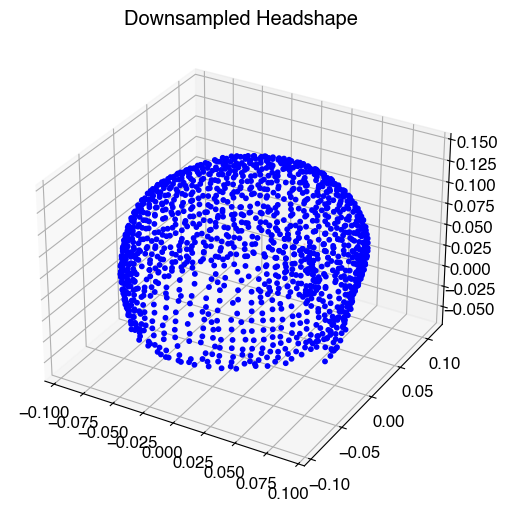

Using pyvistaqt 3d backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
Getting helmet for system unknown (derived from 192 MEG channel locations)
Channel types::	mag: 192
Saving...
Writing /Users/robertseymour/data/study-OPM_training/study-FourMotorOPM/BIDS/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_meg_hs_downsample-raw.fif
Closing /Users/robertseymour/data/study-OPM_training/study-FourMotorOPM/BIDS/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_meg_hs_downsample-raw.fif
[done]


[PosixPath('/Users/robertseymour/data/study-OPM_training/study-FourMotorOPM/BIDS/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_meg_hs_downsample-raw.fif')]

In [6]:
from osl_ephys.source_recon.rhino.utils import downsample_headshape, replace_headshape

%matplotlib inline

filename = os.path.join(
    data_dir,'BIDS',f'sub-{subject}',f'ses-{ses}','meg',
    f'sub-{subject}_ses-{ses}_task-{task}_run-{run}_meg.fif'
)

raw = mne.io.read_raw_fif(filename, preload=True)

# Get Headshape Points
dig = raw.info['dig']
points = np.array([d['r'] for d in dig if 'r' in d])
print(np.shape(points))

# Downsample
ds_headshape = downsample_headshape(
    points,
    downsample_amount=0.01,        # Downsample head mesh (1 cm bins)
    include_facial_info=True,      # Keep facial points for ICP
    remove_zlim=-0.02,             # Remove >2 cm below nasion
    angle=0,                       # No rotation
    method="gridaverage",          # Grid-based averaging
    face_Z=[-0.06, 0.02],          # Keep face: -6 to +2 cm (up-down)
    face_Y=[0.06, 0.15],           # 6–15 cm forward
    face_X=[-0.03, 0.03],          # ±3 cm left-right
    downsample_facial_info=True,   
    downsample_facial_info_amount=0.01  # Downsample face (1 cm bins)
    # shift_inward=True,           # Optional inward shift - coming soon
)

# Assume `raw` is your loaded MNE Raw object, and `ds_headshape` is the Nx3 array of downsampled points
raw_C = replace_headshape(raw, ds_headshape)

# Plot the sensors to check they are in the right orientation
fig = mne.viz.plot_alignment(raw_C.info, dig=True)

# Save the data without duplicating the .fif extension
print('Saving...')
output_filename = '{}_hs_downsample-raw.fif'.format(filename.rstrip('.fif'))
raw_C.save(output_filename, overwrite=True)


## Reload the downsampled headshape version of the raw file

In [6]:
filename = os.path.join(
    data_dir,
    f'BIDS/sub-{subject}/ses-{ses}/meg/'
    f'sub-{subject}_ses-{ses}_task-{task}_run-{run}_meg_hs_downsample-raw.fif'
)

raw = mne.io.read_raw_fif(filename, preload=True)

Opening raw data file /Users/robertseymour/data/study-OPM_training/BIDS/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_meg_hs_downsample-raw.fif...
    Range : 0 ... 2198783 =      0.000 ...  1465.855 secs
Ready.
Reading 0 ... 2198783  =      0.000 ...  1465.855 secs...


## Setup coreg_dir, subjects_dir and path to the structural MRI

In [8]:
# Base coregistration directory inside the BIDS folder
subjects_dir = os.path.join(
    data_dir,
    'BIDS',
    'derivatives',
    'coreg'
)

# Create coreg directory if it does not already exist
os.makedirs(subjects_dir, exist_ok=True)

# Path to the subject's anatomical MRI file
mri_file = os.path.join(
    data_dir,
    'BIDS',
    f'sub-{subject}',
    f'ses-{ses}',
    'anat',
    f'sub-{subject}.nii'
)

# Nicely formatted output
print("\nCoregistration paths:")
print(f"  Subject MEG dir: {subjects_dir}")
print(f"  MRI file       : {mri_file}\n")



Coregistration paths:
  Subject MEG dir: /Users/robertseymour/data/study-OPM_training/BIDS/derivatives/coreg
  MRI file       : /Users/robertseymour/data/study-OPM_training/BIDS/sub-001/ses-001/anat/sub-001.nii



## Run MRI through FSL

In [9]:
source_recon.rhino.compute_surfaces(
    mri_file,
    subjects_dir=subjects_dir,
    subject=subject,
    include_nose=True,
    do_mri2mniaxes_xform=True
)

*** OSL-EPHYS RHINO: USING PREVIOUSLY COMPUTED SURFACES ***
Surfaces directory: /Users/robertseymour/data/study-OPM_training/BIDS/derivatives/coreg/001/rhino/surfaces
include_nose=True


True

## Save the headshape data to subjects_dir

In [10]:
from osl_ephys.source_recon.rhino.utils import save_polhemus_fif
save_polhemus_fif(raw,subjects_dir=subjects_dir,subject=subject)

Saved files to /Users/robertseymour/data/study-OPM_training/BIDS/derivatives/coreg/001/rhino/coreg


## Use RHINO to do the Coreg!

In [11]:
source_recon.rhino.coreg(
    filename,
    subjects_dir=subjects_dir,
    subject=subject,
    use_headshape=True,
    use_nose=True,
    allow_smri_scaling=False,
    n_init = 10,
)

*** RUNNING OSL-EPHYS RHINO COREGISTRATION ***
Opening raw data file /Users/robertseymour/data/study-OPM_training/BIDS/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_meg_hs_downsample-raw.fif...
    Range : 0 ... 2198783 =      0.000 ...  1465.855 secs
Ready.
Creating RawArray with float64 data, n_channels=218, n_times=1
    Range : 0 ... 0 =      0.000 ...     0.000 secs
Ready.
Overwriting existing file.
Writing /Users/robertseymour/data/study-OPM_training/BIDS/derivatives/coreg/001/rhino/coreg/info-raw.fif
Overwriting existing file.
Closing /Users/robertseymour/data/study-OPM_training/BIDS/derivatives/coreg/001/rhino/coreg/info-raw.fif
[done]
The MRI-derived nose is going to be used to aid coreg.
Please ensure that rhino.compute_surfaces was run with include_nose=True.
Please ensure that the polhemus headshape points include the nose.
loading: /Users/robertseymour/data/study-OPM_training/BIDS/derivatives/coreg/001/rhino/coreg/polhemus_headshape.txt
loading: /Users/roberts

### Display Headmodel

In [12]:
source_recon.rhino.bem_display(
    subjects_dir=subjects_dir,
    subject=subject,
    display_outskin_with_nose=False,
    display_sensors=True,
    plot_type="surf",
)

Using pyvistaqt 3d backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
Overwriting existing file.


## Display Coreg Accuracy

#### Note: requires the sensor type to be added to _3d.py MNE code - I need to make a pull request to MNE 

In [13]:
source_recon.rhino.coreg_display(
    subjects_dir=subjects_dir,
    subject=subject,
    display_outskin_with_nose=False,
    display_sensors=True,
    display_sensor_oris = True,
    plot_type="surf",
    display_headshape_pnts=True,
    display_outskin = True,
    # filename='./bem_dispay.html',
)

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
Overwriting existing file.


### Create 8mm single-shell grid

In [14]:
gridstep = 8
source_recon.rhino.forward_model(
    subjects_dir=subjects_dir,
    subject=subject,
    model="Single Layer",
    gridstep=gridstep,
)

*** RUNNING RHINO VOLUMETRIC FORWARD MODEL ***
Using bet_inskull_surf_file for single shell surface
Surface CM = (  -1.6   -6.3   12.0) mm
Surface fits inside a sphere with radius   96.8 mm
Surface extent:
    x =  -75.4 ...   74.2 mm
    y =  -83.1 ...   86.4 mm
    z =  -65.0 ...   83.2 mm
Grid extent:
    x =  -80.0 ...   80.0 mm
    y =  -88.0 ...   88.0 mm
    z =  -72.0 ...   88.0 mm
10143 sources before omitting any.
6963 sources after omitting infeasible sources not within 0.0 - 96.8 mm.
Source spaces are in MRI coordinates.
Checking that the sources are inside the surface and at least    4.0 mm away (will take a few...)
Checking surface interior status for 6963 points...
    Found  365/6963 points inside  an interior sphere of radius   35.6 mm
    Found    0/6963 points outside an exterior sphere of radius   96.8 mm
    Found 3352/6598 points outside using surface Qhull
    Found  268/3246 points outside using solid angles
    Total 3343/6963 points inside the surface
Interior

### Read Forward Solution and Plot

In [15]:
from mne import read_forward_solution

# load forward solution
fwd_fname = os.path.join(subjects_dir, subject, "rhino", "model-fwd.fif")
fwd = read_forward_solution(fwd_fname)

# Visualize the forward solution using plot_alignment() (corrected)
mne.viz.plot_alignment(
    raw.info,  # Use the 'info' from the forward solution
    dig=True,
    subject=subject,  # Name of the subject
    subjects_dir=subjects_dir,  # Path to the subject's MRI directory
    src=fwd['src'],
)

Reading forward solution from /Users/robertseymour/data/study-OPM_training/BIDS/derivatives/coreg/001/rhino/model-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (2863 sources, 192 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
Getting helmet for system unknown (derived from 192 MEG channel locations)
Channel types::	mag: 192
